# CasADi MPC Demo

This notebook demonstrates how to formulate and solve a **Model Predictive Control (MPC)** problem using [CasADi](https://web.casadi.org/).

**System**: Dubins car (unicycle model)
$$\dot{x}_1 = v \cos\theta, \quad \dot{x}_2 = v \sin\theta, \quad \dot{\theta} = \omega, \quad \dot{v} = a$$

**Goal**: Drive the vehicle to the origin while respecting control input bounds.


In [6]:
# Install CasADi if not already available
# !pip install casadi
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

print(f"CasADi version: {ca.__version__}")

CasADi version: 3.7.2


In [7]:
# ── System & MPC parameters ──────────────────────────────────────────────────
dt = 0.05  # discretisation step (s)
N = 20  # prediction horizon (steps)
nx = 4  # state dimension:   [x1, x2, theta, v]
nu = 2  # control dimension: [omega, a]

# Control bounds
omega_max = 1.0  # rad/s
a_max = 1.0  # m/s²
v_max = 2.0  # m/s  (state constraint on speed)

# Cost weights
Q = np.diag([10.0, 10.0, 1.0, 1.0])  # state cost
R = np.diag([0.5, 0.5])  # control cost
Qf = 10 * Q  # terminal state cost

# ── CasADi symbolic variables ────────────────────────────────────────────────
x = ca.SX.sym("x", nx)  # state
u = ca.SX.sym("u", nu)  # control  [omega, a]

# ── Continuous-time dynamics  f(x, u) ────────────────────────────────────────
x1, x2, theta, v = x[0], x[1], x[2], x[3]
omega, a = u[0], u[1]

f_expr = ca.vertcat(
    v * ca.cos(theta),
    v * ca.sin(theta),
    omega,
    a,
)
f = ca.Function("f", [x, u], [f_expr], ["x", "u"], ["xdot"])

# ── Runge-Kutta 4 integrator (one step) ──────────────────────────────────────
k1 = f(x, u)
k2 = f(x + dt / 2 * k1, u)
k3 = f(x + dt / 2 * k2, u)
k4 = f(x + dt * k3, u)
x_next_expr = x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

F = ca.Function("F", [x, u], [x_next_expr], ["x", "u"], ["x_next"])
print("Dynamics functions defined.")
print("  f  : continuous-time RHS")
print("  F  : discrete-time RK4 step")

Dynamics functions defined.
  f  : continuous-time RHS
  F  : discrete-time RK4 step


In [8]:
# ── Build the NLP  ───────────────────────────────────────────────────────────
# Decision variables stacked as:  w = [x_0, u_0, x_1, u_1, ..., x_N]
# Parameters:                     p = x_init  (current state)

# ── Terminal set definition ──────────────────────────────────────────────────
# We use an ellipsoidal terminal set:  (x - x_target)^T P_f (x - x_target) <= c_f
# Here x_target = 0, P_f = identity (can be replaced by a Lyapunov matrix), c_f = terminal set radius
x_target = np.zeros(nx)  # target state (origin)
P_f = np.diag([1.0, 1.0, 0.5, 0.5])  # shape matrix of the terminal ellipsoid
# c_f must be >= the quadratic measure of the *initial* state so the NLP is feasible
# from the start.  For x_init=[1.5,-1,pi/4,0.5]:
#   e^T P_f e  =  1.5^2 + 1^2 + 0.5*(pi/4)^2 + 0.5*0.5^2  ≈ 3.53
# We set c_f slightly above that; the constraint becomes meaningful as the
# trajectory converges toward the origin.
c_f = 5.0  # terminal set radius squared  (tune as needed)

opti = ca.Opti()

# Decision variable matrices (easier indexing)
X = opti.variable(nx, N + 1)  # states   over horizon
U = opti.variable(nu, N)  # controls over horizon
x0_param = opti.parameter(nx)  # current state (parameter, set at run-time)

# ── Objective ────────────────────────────────────────────────────────────────
cost = 0
for k in range(N):
    xe = X[:, k]  # state error (target = origin)
    ue = U[:, k]
    cost += xe.T @ Q @ xe + ue.T @ R @ ue

cost += X[:, N].T @ Qf @ X[:, N]  # terminal cost
opti.minimize(cost)

# ── Constraints ──────────────────────────────────────────────────────────────
# Initial condition
opti.subject_to(X[:, 0] == x0_param)

# Dynamics (multiple-shooting)
for k in range(N):
    opti.subject_to(X[:, k + 1] == F(X[:, k], U[:, k]))

# Control bounds
opti.subject_to(opti.bounded(-omega_max, U[0, :], omega_max))
opti.subject_to(opti.bounded(-a_max, U[1, :], a_max))

# State constraint: speed limit
opti.subject_to(opti.bounded(-v_max, X[3, :], v_max))

# ── Terminal set constraint ──────────────────────────────────────────────────
# Enforce:  (x_N - x_target)^T P_f (x_N - x_target) <= c_f
x_N = X[:, N]
e_N = x_N - x_target  # terminal state error (CasADi MX)
terminal_set_constraint = e_N.T @ P_f @ e_N  # scalar quadratic form
opti.subject_to(terminal_set_constraint <= c_f)
print(
    f"Terminal set: ellipsoid  e^T P_f e <= {c_f}  (P_f = diag{np.diag(P_f).tolist()})"
)

# ── Solver ───────────────────────────────────────────────────────────────────
opts = {
    "ipopt.print_level": 0,
    "ipopt.max_iter": 500,
    "print_time": False,
}
opti.solver("ipopt", opts)
print("NLP built successfully.")
print(f"  Decision variables : {nx*(N+1) + nu*N}")
print(
    f"  Constraints        : {nx*N + nx + 2*nu + (N+1) + 1} (approx, +1 for terminal set)"
)

Terminal set: ellipsoid  e^T P_f e <= 5.0  (P_f = diag[1.0, 1.0, 0.5, 0.5])
NLP built successfully.
  Decision variables : 124
  Constraints        : 110 (approx, +1 for terminal set)


In [9]:
# ── Closed-loop MPC simulation ───────────────────────────────────────────────
x_init = np.array([1.5, -1.0, np.pi / 4, 0.5])  # initial state
x_cur = x_init.copy()
T_sim = 200  # max simulation steps

traj_x = [x_cur.copy()]
traj_u = []

# Warm-start: initialise decision variables to zero
opti.set_initial(X, np.zeros((nx, N + 1)))
opti.set_initial(U, np.zeros((nu, N)))

for step in range(T_sim):
    opti.set_value(x0_param, x_cur)

    try:
        sol = opti.solve()
        u_opt = sol.value(U[:, 0])
        X_pred = sol.value(X)

        # Warm-start next iteration with shifted solution
        opti.set_initial(opti.lam_g, sol.value(opti.lam_g))
        opti.set_initial(X, np.hstack([X_pred[:, 1:], X_pred[:, [-1]]]))
        opti.set_initial(U, np.hstack([sol.value(U)[:, 1:], sol.value(U)[:, [-1]]]))

    except Exception as e:
        print(f"Solver failed at step {step}: {e}")
        break

    # Apply first control, simulate one step
    x_cur = np.array(F(x_cur, u_opt)).flatten()
    traj_x.append(x_cur.copy())
    traj_u.append(u_opt.copy())

    # Stop early if close to origin
    if np.linalg.norm(x_cur[:2]) < 0.05:
        print(f"Reached target at step {step + 1}  (t = {(step+1)*dt:.2f} s)")
        break

traj_x = np.array(traj_x)
traj_u = np.array(traj_u)
print(f"Simulation finished. Total steps: {len(traj_u)}")

Simulation finished. Total steps: 200


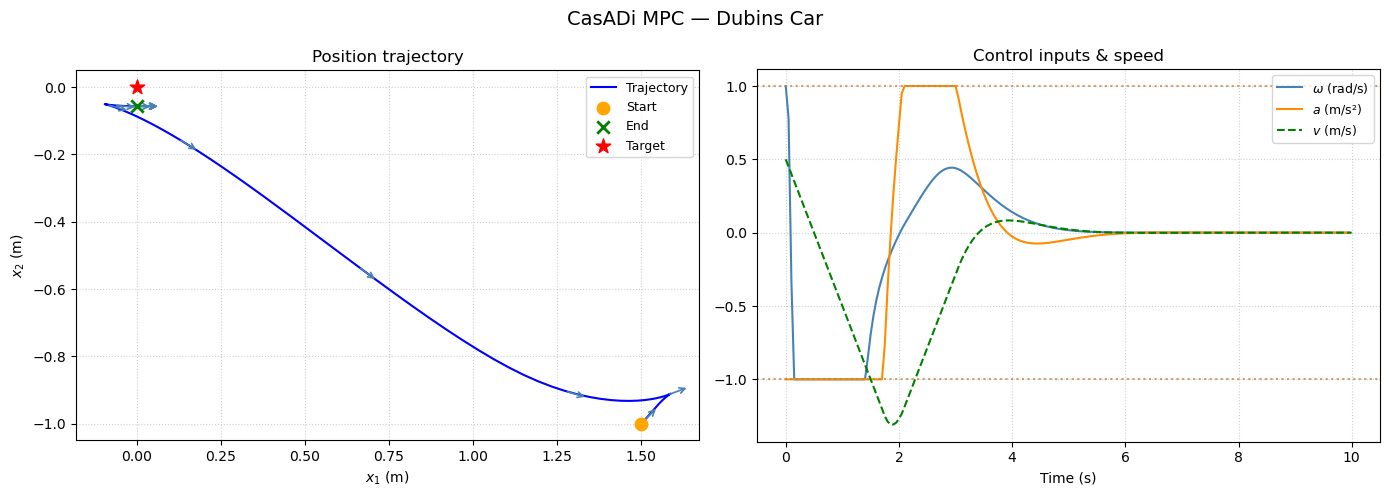

In [10]:
# ── Visualisation ────────────────────────────────────────────────────────────
if len(traj_u) == 0:
    print("No control data to plot — solver failed at every step.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("CasADi MPC — Dubins Car", fontsize=14)

    # ── Left: x1-x2 trajectory ───────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(traj_x[:, 0], traj_x[:, 1], "b-", linewidth=1.5, label="Trajectory")
    ax.scatter(*traj_x[0, :2], s=80, c="orange", zorder=5, label="Start")
    ax.scatter(
        *traj_x[-1, :2], s=80, c="green", marker="x", linewidth=2, zorder=5, label="End"
    )
    ax.scatter(0, 0, s=120, c="red", marker="*", zorder=5, label="Target")

    # Draw heading arrows every few steps
    for k in range(0, len(traj_x) - 1, max(1, len(traj_x) // 15)):
        dx = 0.07 * np.cos(traj_x[k, 2])
        dy = 0.07 * np.sin(traj_x[k, 2])
        ax.annotate(
            "",
            xy=(traj_x[k, 0] + dx, traj_x[k, 1] + dy),
            xytext=(traj_x[k, 0], traj_x[k, 1]),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.2),
        )

    ax.set_xlabel("$x_1$ (m)")
    ax.set_ylabel("$x_2$ (m)")
    ax.set_title("Position trajectory")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_aspect("equal")

    # ── Right: control inputs & speed ────────────────────────────────────────────
    ax2 = axes[1]
    t = np.arange(len(traj_u)) * dt
    ax2.plot(t, traj_u[:, 0], label="$\\omega$ (rad/s)", color="steelblue")
    ax2.plot(t, traj_u[:, 1], label="$a$ (m/s²)", color="darkorange")
    ax2.plot(
        np.arange(len(traj_x)) * dt,
        traj_x[:, 3],
        label="$v$ (m/s)",
        color="green",
        linestyle="--",
    )
    ax2.axhline(omega_max, color="steelblue", linestyle=":", alpha=0.5)
    ax2.axhline(-omega_max, color="steelblue", linestyle=":", alpha=0.5)
    ax2.axhline(a_max, color="darkorange", linestyle=":", alpha=0.5)
    ax2.axhline(-a_max, color="darkorange", linestyle=":", alpha=0.5)
    ax2.set_xlabel("Time (s)")
    ax2.set_title("Control inputs & speed")
    ax2.legend(fontsize=9)
    ax2.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()